# Rusty-ECU Engine Simulations

The rusty-ecu needs a better, more realistic way of simulating the crank sensor. Currently, client code
(both in the simulator and on the ecu) just increments the crank sensor by a fixed amount, or by adding a
proportional amount associated with the throttle position.

This notebook seeks to find a good differential equation that we can use as a mathematical model for an
engine. At least a very very very loose approximation: just to get the *feel* right to the user of the
simulator.

The equation we'll be simulating is:

$$
J \frac{d\omega}{dt} = T_{engine}(\theta) - b\omega(t)
$$

Where:
* $J$ is angular moment of inertia
* $b$ is damping coefficient
* $T_{engine}(\theta)$ is engine torque as a function of throttle position ($\theta$)
* $T_{engine}(\theta) = T_{idle} + \theta * max(\text{torque})$

Note the time constant is: $\tau = \frac{J}{b}$

(This should be updated as I go along and develop this equation)

In [37]:
# Import needed libraries
import numpy as np
import matplotlib.pyplot as plt

In [38]:
# Constants for this simulation
DT_S = 0.005 # 5 ms delta
T_END = 20.0 # 10 seconds sim
IDLE_T = 5.0 # Torque always produced by engine while it's on, even with zero throttle
MAX_T = 20.0 # Maximum torque added by throttle
B = 1.0      # Damping coefficient - makes it so the system damps itself
J = 1.4      # Moment of inertia - dictates how much an object with mass resists change

Text(0, 0.5, 'Crankshaft Angle (degrees)')

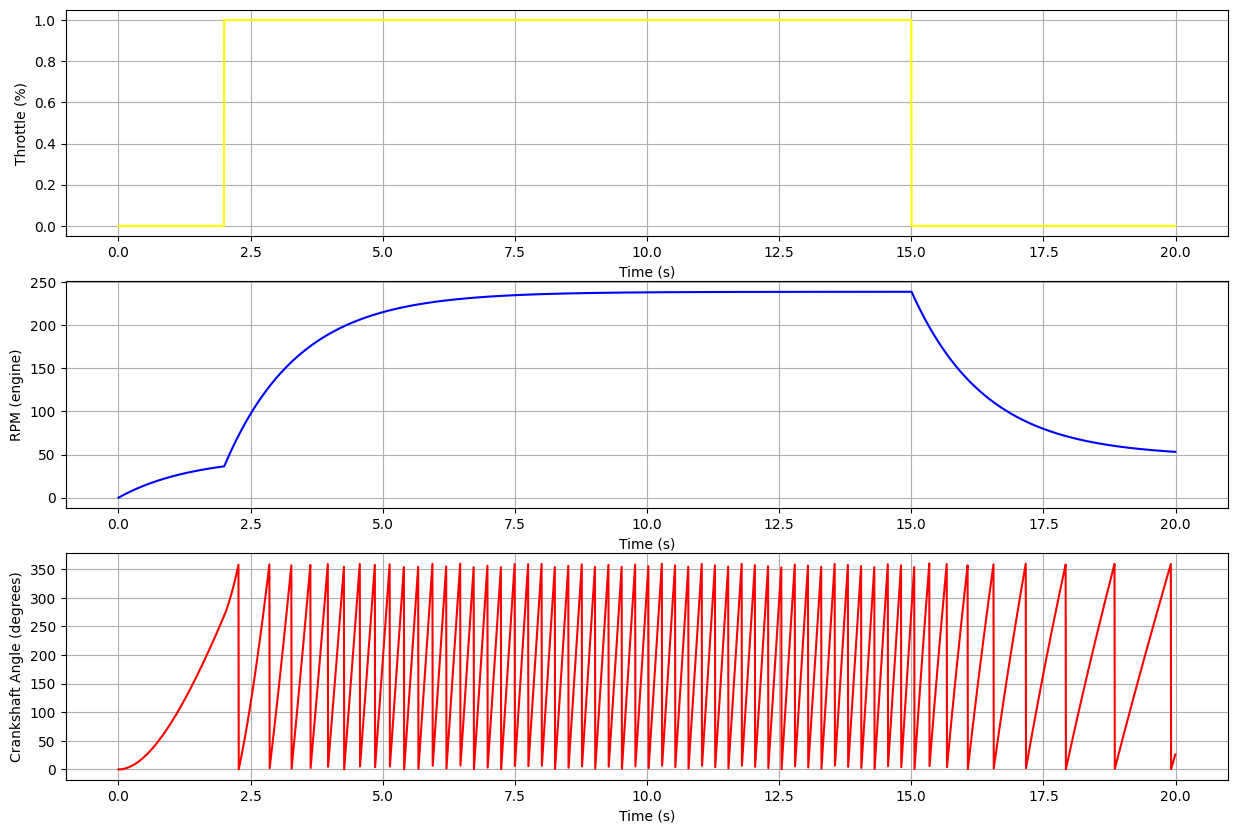

In [39]:
# Run time-domain simulation
t = np.arange(0, T_END, DT_S)
n = len(t)

# Input
throttle = np.zeros(n)
throttle[(t >= 2) & (t <= 15)] = 1.0

# State
omega = np.zeros(n)
angle = np.zeros(n)

for i in range(n - 1):
    # t_engine = IDLE_T + throttle[i] * MAX_T
    t_engine = IDLE_T + throttle[i] * MAX_T # Constant torque added
    t_friction = B * omega[i] # Pretend friction
    t_net = t_engine - t_friction
    alpha = t_net / J

    omega[i+1] = omega[i] + alpha * DT_S

    # Not needed yet, but if we add negative terms, will clamp
    if omega[i+1] < 0:
        omega[i+1] = 0

    # Calculate change in angle
    delta_deg = omega[i+1] * DT_S * (180 / np.pi)
    angle[i+1] = (angle[i] + delta_deg) % 360.0

rpm = omega * (60 / (2 * np.pi))

fix, axes = plt.subplots(3, 1, figsize=(15,10))
axes[0].plot(t, throttle, color='yellow')
axes[0].grid()
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Throttle (%)')

axes[1].plot(t, rpm, color='blue')
axes[1].grid()
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('RPM (engine)')

axes[2].plot(t, angle, color='red')
axes[2].grid()
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Crankshaft Angle (degrees)')


